In [2]:
from pathlib import Path

import numpy as np
import pydicom
import SimpleITK as sitk
import matplotlib.pyplot as plt

from pydosert.data.utils.dicom_utils import load_ct_series, load_structures
from pydosert.utils.plotting import overlay_mask_outline

ct_folder = Path("CPPP-IMRT/CT")
rtstruct_path = "CPPP-IMRT/RS.CPPP.PHANTOM.dcm"

# ROI display colours straight from the RTSTRUCT
_rs = pydicom.dcmread(rtstruct_path)
_num_to_name = {r.ROINumber: r.ROIName for r in _rs.StructureSetROISequence}
roi_colors = {
    _num_to_name[c.ReferencedROINumber]: tuple(v / 255 for v in c.ROIDisplayColor)
    for c in _rs.ROIContourSequence
}
print("ROIs in structure set:", roi_colors)

ROIs in structure set: {'BODY': (0.0, 1.0, 0.0), 'Center': (1.0, 0.0, 1.0), 'Avoid1': (1.0, 0.0, 0.2), 'Avoid2': (0.9019607843137255, 0.6705882352941176, 0.00784313725490196)}


---
## ⚠ Modifications to `pydosert` made in this notebook

Written against **pydosert 1.4.0**. **No files on disk are changed.** All modifications
are made in memory in this kernel, so restarting the kernel always gives stock
pydosert. The patched functions copy pydosert internals, so check them again after a
pydosert upgrade.

| ID | What changes | Where | Why | Scope | How to revert |
|----|--------------|-------|-----|-------|---------------|
| **M1** | Plan parser: tolerates control points without `SourceToSurfaceDistance`, reads the ASYMX jaws, clips leaves to them, and records the X-jaw positions per control point | replaces `pydosert.data.loaders.fetch_plan_data` | Stock parser crashes on this plan (no SSD) and ignores the X jaws | global, from the setup cell on | `revert_pydosert_patches()` |
| **M2** | FFT convolution in place of grouped `conv2d` (same maths, verified to ~5e-6 relative) | replaces `BeamWiseConvolutionalLayer.forward` | Speed only: about 1 min instead of about 7 h on CPU. **Does not change the result.** | global, from the setup cell on | `revert_pydosert_patches()` |
| **M3** | Delivery segments use the true ΔMU between control points *i* and *i+1* instead of `to_delivery()`'s averaged MU | notebook code only (`dataclasses.replace(...)`); pydosert is not patched | `to_delivery()` shifts the arc's MU weighting by half a segment | the `delivery` variable | use `control_points.to_delivery()` directly |
| **M4** | **Physics correction:** X jaws added to the fluence model. The MLC transmission is blocked outside the X jaws, and the output factor uses the real X-jaw width instead of 400 mm | replaces `FluenceMapLayer.forward`, **only inside `with xjaw_fluence_model(...)`** | Stock pydosert models only the Y jaws: about 1.5 Gy of excess leakage dose and a +3 % output-factor error | only the *Corrected* and *Refined model* sections; removed automatically when the `with` block exits | set `APPLY_M4 = False`, or don't use the `with` block |
| **M5** | **Physics correction:** dosimetric leaf gap `dlg_mm = 1.0` (the `tb3_test` preset has none) | `MachineConfig(preset="tb3_test", dlg_mm=DLG_MM)`: a config override, not a patch | Rounded leaf ends: the stock model underdoses small VMAT openings | the *Corrected* and *Refined* engines | set `DLG_MM = None` |
| **M6** | **Physics correction:** leaf pairs with a gap < 1.5 mm keep their planned gap but get **no DLG widening** | option inside the M4 patch: `xjaw_fluence_model(..., close_gap_mm=CLOSE_GAP_MM)` | In this plan the two central leaf pairs sit 1.1 mm apart during the heaviest part of the arc (gantry 47–63°, ≈150 MU). The DLG widened that to a 2.1 mm fully open slit, a streak of +2–4 Gy through Avoid2 and along Avoid1 | only the *Refined model* section | set `CLOSE_GAP_MM = None` |
| **M7** | **Physics correction:** leaf-end (MLC-direction) source penumbra 1.18 → 2.0 mm FWHM; leaf sides / Y jaws unchanged | `MachineConfig(..., penumbra_fwhm=[PEN_MLC_MM, 1.1775])`: a config override | Rounded leaf ends give a broader dose tail beyond the leaf tip than a sharp edge does | only the *Refined model* engine | set `PEN_MLC_MM = None` |
| **C1** | **Comparison method, not a pydosert change:** pydosert is computed on a grid whose points coincide with the TPS dose grid (extended to cover the whole phantom), and compared with the TPS dose **without interpolating it** | *Refined model* section | The stock/corrected sections interpolate the TPS dose onto pydosert's grid (offset by 0.5–0.6 voxel, 2.5 → 2 mm slices). In Avoid2's steep gradient that alone shifts the DVH by several % | only the *Refined model* section | the earlier sections are the CT-grid comparison |

M1–M3 are needed to run this plan at all (M2 only for speed). **The stock-model results
below use M1–M3 only.** M4 and M5 are the physics corrections used in the *Corrected
model* section. The *Refined model* section adds M6, M7 and C1 to fix Avoid2.
**M5 (DLG 1.0 mm) and M7 (leaf-end penumbra 2.0 mm) are fitted** against this TPS dose.
Replace them with the TPS beam-model values for this machine once those are known.

Check what's active at any time with `list_pydosert_patches()`.

---
## VMAT dose: `pydosert` (`tb3_test` machine) vs TPS

`RP.CPPP.IMRT.dcm` is a single **6 MV VMAT arc** (gantry 181° → 179° CW, 180 control
points, 60-pair Millennium-120 MLC, jaws X ±29 / Y ±27 mm, 665.3 MU, 25 fx × 2 Gy to
`Center`). We recompute it with `pydosert`'s pencil-beam `DoseEngine` using the
`tb3_test` machine preset, then compare against the TPS dose (`RD.CPPP.IMRT.dcm`)
voxel by voxel.

Notes on the setup:

* **CT is a placeholder** (every voxel −1000 HU), so the density grid is overridden with
  the RTSTRUCT's own override: `BODY` REL_ELEC_DENSITY = 1.0034, everything else air.
* **[M1] Plan parser.** The stock `fetch_plan_data` reads `cp.SourceToSurfaceDistance`
  (absent in this plan → `AttributeError`) and ignores the ASYMX jaws. The patched parser
  below handles both (leaves are clipped to the X jaws).
* **[M3] Delivery MU.** `BeamSequence.to_delivery()` averages the per-control-point MU
  increments, which offsets the arc's MU weighting by half a segment and drops half the
  last segment's MU. We keep its averaged leaf / jaw / gantry positions but use the true
  segment MU (`ΔMU` between control points *i* and *i+1*).
* **[M2] FFT convolution.** The engine convolves every (control point, depth) plane with a
  151 × 151 kernel through grouped `conv2d`. On CPU that takes hours for 179 segments, so
  it's swapped for a mathematically identical FFT convolution (verified against `conv2d`
  to ~5e-6 relative error).

This section is the **stock `tb3_test` model**. It has no X jaws and no DLG (see M4 / M5).

In [3]:
import dataclasses
import math
import time

import torch

import pydosert.data.loaders as _ld
from pydosert.data.beam import Beam
from pydosert.data.loaders import load_dicom
from pydosert.data import MachineConfig
from pydosert import DoseEngine
from pydosert.layers.BeamWiseConvolutionalLayer import BeamWiseConvolutionalLayer

torch.set_grad_enabled(False)
DEVICE = torch.device("cpu")
DTYPE = torch.float32

rtplan_path = "CPPP-IMRT/RP.CPPP.IMRT.dcm"
rtdose_path = "CPPP-IMRT/RD.CPPP.IMRT.dcm"


# ---- Patch registry: every global pydosert modification goes through _patch() ----------
# Originals are stored so revert_pydosert_patches() restores stock pydosert in this kernel.
_PYDOSERT_ORIGINALS = {}   # (owner, attribute) -> (original object, patch ID)


def _patch(owner, attr, replacement, patch_id):
    if (owner, attr) not in _PYDOSERT_ORIGINALS:
        _PYDOSERT_ORIGINALS[(owner, attr)] = (getattr(owner, attr), patch_id)
    setattr(owner, attr, replacement)


def list_pydosert_patches():
    """Print the pydosert objects currently replaced by this notebook."""
    if not _PYDOSERT_ORIGINALS:
        print("no pydosert patches active (stock pydosert)")
    for (owner, attr), (_, pid) in _PYDOSERT_ORIGINALS.items():
        print(f"  [{pid}] {getattr(owner, '__name__', owner)}.{attr}")


def revert_pydosert_patches():
    """Restore every patched pydosert object to its original (undoes M1 + M2)."""
    for (owner, attr), (orig, pid) in _PYDOSERT_ORIGINALS.items():
        setattr(owner, attr, orig)
        print(f"reverted [{pid}] {getattr(owner, '__name__', owner)}.{attr}")
    _PYDOSERT_ORIGINALS.clear()


# [M1] X-jaw positions per control point, recorded by the parser for M4:
#      {"<SOPInstanceUID>_<BeamNumber>": np.ndarray [CP, 2] (mm)}
PLAN_X_JAWS = {}


def fetch_plan_data_imrt(plan_path):
    """[M1] Drop-in for pydosert's fetch_plan_data: tolerates control points without
    SourceToSurfaceDistance, clips the MLC leaves to the ASYMX jaws and records the
    X-jaw positions in PLAN_X_JAWS (used by M4)."""
    ds = pydicom.dcmread(str(plan_path))
    fg = ds.FractionGroupSequence[0]
    n_frac = int(fg.NumberOfFractionsPlanned)
    metersets = {str(rb.ReferencedBeamNumber): float(rb.BeamMeterset)
                 for rb in fg.ReferencedBeamSequence if hasattr(rb, "BeamMeterset")}

    params = {}
    for beam in ds.BeamSequence:
        mu_tot = metersets.get(str(beam.BeamNumber))
        if mu_tot is None:
            continue
        gantry = coll = 0.0
        ssd = iso = None
        jaw_x = jaw_y = leaves = None
        old_mu, beams, x_jaws = 0.0, [], []
        for cp in beam.ControlPointSequence:            # later CPs only carry what changes
            if cp.get("GantryAngle") is not None:              gantry = float(cp.GantryAngle)
            if cp.get("BeamLimitingDeviceAngle") is not None:  coll = float(cp.BeamLimitingDeviceAngle)
            if cp.get("SourceToSurfaceDistance") is not None:  ssd = float(cp.SourceToSurfaceDistance)
            if cp.get("IsocenterPosition") is not None and iso is None:
                ip = cp.IsocenterPosition
                iso = (float(ip[2]), float(ip[1]), float(ip[0]))
            for s in cp.get("BeamLimitingDevicePositionSequence", []):
                p = np.array([float(v) for v in s.LeafJawPositions])
                if s.RTBeamLimitingDeviceType in ("ASYMX", "X"):   jaw_x = p
                elif s.RTBeamLimitingDeviceType in ("ASYMY", "Y"): jaw_y = p
                elif s.RTBeamLimitingDeviceType == "MLCX":
                    leaves = np.stack([p[: len(p) // 2], p[len(p) // 2:]], 1)

            mu_val = mu_tot * float(cp.CumulativeMetersetWeight)
            beams.append(Beam(
                gantry_angle=math.radians(gantry),
                collimator_angle=math.radians(coll),
                ssd=ssd,
                mu=torch.from_numpy(np.array(mu_val - old_mu)),
                leaf_positions=torch.from_numpy(np.clip(leaves, jaw_x[0], jaw_x[1])),
                jaw_positions=torch.from_numpy(jaw_y.copy()),
                field_size=(400, 400),
                sid=float(beam.SourceAxisDistance),
                iso_center=iso,
            ))
            x_jaws.append(jaw_x.copy())
            old_mu = mu_val
        if beams:
            key = f"{ds.SOPInstanceUID}_{beam.BeamNumber}"
            params[key] = (beams, n_frac)
            PLAN_X_JAWS[key] = np.stack(x_jaws)
    return params


def _fft_beamwise_conv(self, fluence_vol, kernels, chunk=256):
    """[M2] FFT equivalent of BeamWiseConvolutionalLayer.forward (grouped conv2d, padding='same')."""
    BG, D, H, W, _ = fluence_vol.shape
    kH, kW = kernels.shape[0], kernels.shape[1]
    x = fluence_vol.reshape(BG * D, H, W)
    k = kernels.permute(2, 3, 0, 1).reshape(BG * D, kH, kW).flip(-2, -1)  # conv2d is a correlation
    fh, fw = H + kH - 1, W + kW - 1
    ph, pw = (kH - 1) // 2, (kW - 1) // 2
    out = torch.empty_like(x)
    for s in range(0, BG * D, chunk):
        e = min(s + chunk, BG * D)
        y = torch.fft.irfft2(torch.fft.rfft2(x[s:e], s=(fh, fw)) * torch.fft.rfft2(k[s:e], s=(fh, fw)),
                             s=(fh, fw))
        out[s:e] = y[:, ph:ph + H, pw:pw + W]
    return out.view(BG, D, H, W, 1)


_patch(_ld, "fetch_plan_data", fetch_plan_data_imrt, "M1")
_patch(BeamWiseConvolutionalLayer, "forward", _fft_beamwise_conv, "M2")
list_pydosert_patches()

  [M1] pydosert.data.loaders.fetch_plan_data
  [M2] BeamWiseConvolutionalLayer.forward


In [4]:
# Load CT + structures + plan + reference dose onto pydosert's 2 mm dose grid
patient, beam_sequences = load_dicom(
    ct_folder,
    dose_path=[rtdose_path],
    plan_path=[rtplan_path],
    struct_path=rtstruct_path,
    struct_names=list(roi_colors),
    device="cpu",
    dtype=DTYPE,
    crop_volume=True,
)
patient = patient.to("cpu").to(DTYPE)
control_points = beam_sequences[0].to("cpu")

# [M3] N+1 control points -> N delivery segments; keep the true segment MU (see note above).
#      Revert: delivery = control_points.to_delivery()
delivery = dataclasses.replace(control_points.to_delivery(), mus=control_points.mus[1:].clone())

# X jaws per delivery segment (mean of adjacent control points), only used by M4
_xj_cp = PLAN_X_JAWS[next(iter(PLAN_X_JAWS))]
xjaw_delivery = torch.from_numpy((_xj_cp[:-1] + _xj_cp[1:]) / 2).to(DTYPE)       # [N, 2] mm

dose_masks = patient.structures                 # {name: bool tensor [D, H, W]} on the dose grid
n_fx = patient.number_of_fractions
res = tuple(patient.resolution)

# CT is a placeholder (all air) -> RTSTRUCT density override: BODY = 1.0034, else air
body_red = next(float(p.ROIPhysicalPropertyValue)
                for o in _rs.RTROIObservationsSequence
                if _num_to_name[o.ReferencedROINumber] == "BODY"
                for p in o.get("ROIPhysicalPropertiesSequence", []))
density = torch.where(dose_masks["BODY"], body_red, 0.0012).to(DTYPE)

# isocentre voxel (iso_center is (z, y, x) mm relative to the grid origin)
iso_idx = tuple(int(round(c / r)) for c, r in zip(control_points.iso_center, res))

print("dose grid (D, H, W):", tuple(density.shape), " voxel (mm):", res, " fractions:", n_fx)
print(f"BODY density override: {body_red:.4f}   isocentre voxel (z, y, x): {iso_idx}")
g = delivery.gantry_angles_deg
print(f"{len(delivery)} delivery segments, gantry {float(g[0]):.0f} -> {float(g[-1]):.0f} deg, "
      f"total MU = {float(delivery.mus.sum()):.1f}")

dose grid (D, H, W): (104, 150, 150)  voxel (mm): (2.0, 2.0, 2.0)  fractions: 25
BODY density override: 1.0034   isocentre voxel (z, y, x): (51, 75, 75)
179 delivery segments, gantry 182 -> 178 deg, total MU = 665.3


In [5]:
# tb3_test machine model + pencil-beam engine (auto-calibrated), full-arc dose
machine = MachineConfig(preset="tb3_test")
print(f"tb3_test: TPR20/10 = {machine.tpr_20_10}, {machine.number_of_leaf_pairs} leaf pairs, "
      f"calibration MU = {machine.calibration_mu}")

engine = DoseEngine(
    machine_config=machine,
    kernel_size=151,
    dose_grid_spacing=res,
    dose_grid_shape=tuple(density.shape),
    device=DEVICE,
    dtype=DTYPE,
    auto_calibrate=True,
)

t0 = time.time()
dose_fx = engine.compute_dose(delivery, density_image=density).squeeze(0)   # Gy / fraction
print(f"dose computed in {time.time() - t0:.0f} s")

dose_plan = dose_fx * n_fx                  # pydosert, full course (Gy)
ref_plan = patient.dose * n_fx              # TPS reference, full course (Gy)
dp = dose_plan.cpu().numpy()
rp = ref_plan.cpu().numpy()

print(f"pydosert  Dmax = {dp.max():.2f} Gy   (per fraction {dp.max() / n_fx:.3f} Gy)")
print(f"TPS ref   Dmax = {rp.max():.2f} Gy   (per fraction {rp.max() / n_fx:.3f} Gy)")
print(f"at isocentre: pydosert {dp[iso_idx]:.2f} Gy   TPS {rp[iso_idx]:.2f} Gy   "
      f"Δ = {100 * (dp[iso_idx] / rp[iso_idx] - 1):+.1f} %")

tb3_test: TPR20/10 = 0.6653, 60 leaf pairs, calibration MU = 120.5


c:\Users\mross\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydosert\engine\dose_engine.py:265: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtypes of torch.bfloat16, torch.float16 currently.
  with torch.amp.autocast(self.device.type, dtype=self.dtype):


dose computed in 76 s
pydosert  Dmax = 66.93 Gy   (per fraction 2.677 Gy)
TPS ref   Dmax = 64.13 Gy   (per fraction 2.565 Gy)
at isocentre: pydosert 59.95 Gy   TPS 59.87 Gy   Δ = +0.1 %


### Per-structure DVH statistics

For each ROI, both dose cubes are summarised with first-order statistics, DVH points
(D98 / D95 / D50 / D2 %, D2cc) and, for `Center` (Rx 50 Gy), the homogeneity index and
V95 / V100 / V107 %Rx.

In [6]:
from pydosert.objectives.metrics import dose_at_volume_percent, dose_at_volume_cc, volume_at_dose

voxel_cc = float(np.prod(res)) / 1000.0
rx_gy = {"Center": 2.0 * n_fx}


def dvh_statistics(dose3d, mask, rx=None):
    d = dose3d[mask]
    s = {
        "n_vox": float(d.size), "volume_cc": d.size * voxel_cc,
        "Dmin": float(d.min()), "Dmax": float(d.max()), "Dmean": float(d.mean()),
        "Dstd": float(d.std()), "Dmedian": float(np.median(d)),
        "D98%": dose_at_volume_percent(dose3d, mask, 98.0),
        "D95%": dose_at_volume_percent(dose3d, mask, 95.0),
        "D50%": dose_at_volume_percent(dose3d, mask, 50.0),
        "D2%":  dose_at_volume_percent(dose3d, mask, 2.0),
        "D2cc": dose_at_volume_cc(dose3d, mask, 2.0, voxel_cc),
    }
    if rx:
        s["HI"] = (s["D2%"] - s["D98%"]) / s["D50%"]
        s["V95%Rx_%"] = volume_at_dose(dose3d, mask, 0.95 * rx)
        s["V100%Rx_%"] = volume_at_dose(dose3d, mask, 1.00 * rx)
        s["V107%Rx_%"] = volume_at_dose(dose3d, mask, 1.07 * rx)
    return s


np_masks = {name: m.cpu().numpy() for name, m in dose_masks.items()}
for name, mk in np_masks.items():
    a, b = dvh_statistics(dp, mk, rx_gy.get(name)), dvh_statistics(rp, mk, rx_gy.get(name))
    hdr = f"Rx = {rx_gy[name]:g} Gy" if name in rx_gy else "(no prescription)"
    print(f"\n=== {name}   {hdr} " + "=" * max(4, 40 - len(name) - len(hdr)))
    print(f"{'metric':11s} {'pydosert':>10s} {'TPS':>10s} {'Δ (pd−TPS)':>11s} {'Δ %':>8s}")
    for k in a:
        if k == "n_vox":
            print(f"{k:11s} {a[k]:10.0f} {b[k]:10.0f}")
            continue
        pct = 100.0 * (a[k] - b[k]) / b[k] if b[k] else float("nan")
        print(f"{k:11s} {a[k]:10.3f} {b[k]:10.3f} {a[k] - b[k]:+11.3f} {pct:+8.1f}")


=== BODY   (no prescription) ===================
metric        pydosert        TPS  Δ (pd−TPS)      Δ %
n_vox          1009503    1009503
volume_cc     8076.024   8076.024      +0.000     +0.0
Dmin             0.105      0.055      +0.050    +89.4
Dmax            66.930     64.129      +2.801     +4.4
Dmean            3.698      3.175      +0.523    +16.5
Dstd             7.165      6.757      +0.408     +6.0
Dmedian          0.675      0.480      +0.195    +40.7
D98%             0.175      0.129      +0.047    +36.3
D95%             0.205      0.151      +0.054    +35.6
D50%             0.675      0.480      +0.195    +40.7
D2%             25.394     24.106      +1.289     +5.3
D2cc            62.985     60.790      +2.194     +3.6

=== Center   Rx = 50 Gy ========================
metric        pydosert        TPS  Δ (pd−TPS)      Δ %
n_vox             4688       4688
volume_cc       37.504     37.504      +0.000     +0.0
Dmin            34.847     38.587      -3.739     -9.7
Dmax   

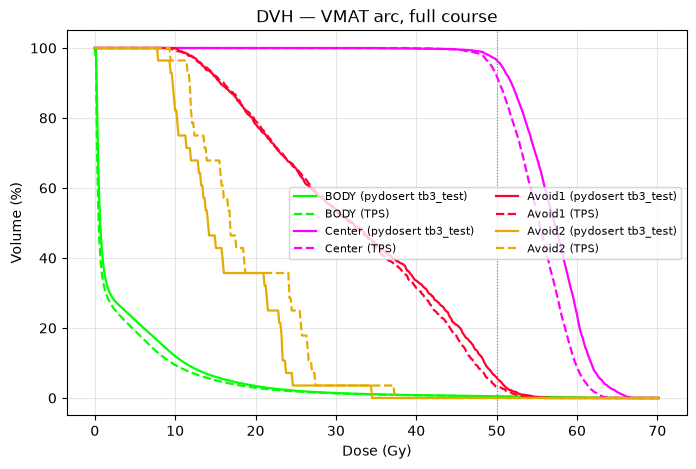

In [7]:
# Cumulative DVH, all ROIs: pydosert (solid) vs TPS (dashed)
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, max(dp.max(), rp.max()) * 1.05, 500)
for name, mk in np_masks.items():
    for arr, ls, tag in ((dp, "-", "pydosert tb3_test"), (rp, "--", "TPS")):
        h, edges = np.histogram(arr[mk], bins=bins)
        ax.plot(edges[:-1], 100 * np.cumsum(h[::-1])[::-1] / h.sum(), ls=ls,
                color=roi_colors[name], lw=1.6, label=f"{name} ({tag})")
ax.axvline(rx_gy["Center"], color="gray", lw=0.8, ls=":")
ax.set_xlabel("Dose (Gy)")
ax.set_ylabel("Volume (%)")
ax.set_title("DVH — VMAT arc, full course")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.show()

### Voxel-by-voxel comparison over the whole dose grid

1. Dose-difference statistics (whole grid, above a 10 % low-dose cutoff, and per ROI).
2. Per-voxel correlation (pydosert vs TPS, one point per voxel).
3. 3-D global gamma (3 %/3 mm and 2 %/2 mm, 10 % cutoff) via `pymedphys.gamma`.

entire grid              n= 2340000  mean Δ= +0.606  mean |Δ|= 0.616  RMSE= 1.151  95th |Δ|= 2.799  max |Δ|=12.410  (Gy)
grid, dose > 10% max     n=  161751  mean Δ= +1.497  mean |Δ|= 1.585  RMSE= 1.740  95th |Δ|= 2.590  max |Δ|= 8.128  (Gy)
BODY                     n= 1009503  mean Δ= +0.523  mean |Δ|= 0.543  RMSE= 0.909  95th |Δ|= 2.030  max |Δ|= 8.894  (Gy)
Center                   n=    4688  mean Δ= +1.787  mean |Δ|= 1.840  RMSE= 2.129  95th |Δ|= 3.983  max |Δ|= 6.373  (Gy)
Avoid1                   n=    1276  mean Δ= +0.403  mean |Δ|= 0.933  RMSE= 1.254  95th |Δ|= 2.701  max |Δ|= 4.948  (Gy)
Avoid2                   n=      28  mean Δ= -2.541  mean |Δ|= 2.541  RMSE= 2.581  95th |Δ|= 3.200  max |Δ|= 3.251  (Gy)


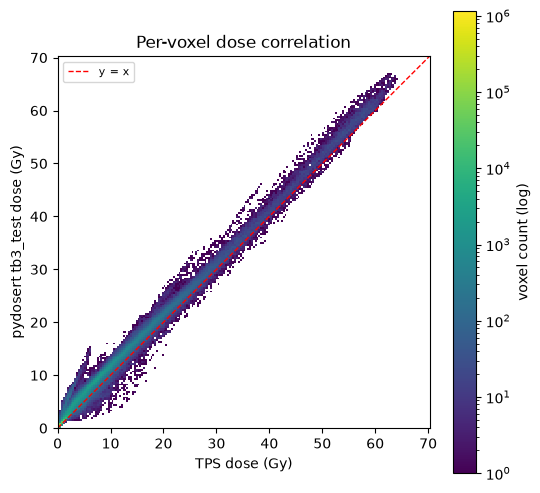

Pearson r (all voxels) = 0.9816   fit above 10% cutoff: slope = 0.995, intercept = +1.57 Gy


In [8]:
diff = dp - rp
above_cutoff = rp > 0.10 * rp.max()


def diff_stats(mask, label):
    d = diff[mask]
    print(f"{label:24s} n={d.size:>8d}  mean Δ={d.mean():+7.3f}  mean |Δ|={np.abs(d).mean():6.3f}  "
          f"RMSE={np.sqrt((d ** 2).mean()):6.3f}  95th |Δ|={np.percentile(np.abs(d), 95):6.3f}  "
          f"max |Δ|={np.abs(d).max():6.3f}  (Gy)")


diff_stats(np.ones(rp.shape, bool), "entire grid")
diff_stats(above_cutoff, "grid, dose > 10% max")
for name, mk in np_masks.items():
    diff_stats(mk, name)

# Per-voxel correlation
fig, ax = plt.subplots(figsize=(6, 6))
lim = float(max(dp.max(), rp.max())) * 1.05
hb = ax.hist2d(rp.ravel(), dp.ravel(), bins=200, range=[[0, lim], [0, lim]],
               cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
ax.plot([0, lim], [0, lim], "r--", lw=1, label="y = x")
ax.set_xlabel("TPS dose (Gy)")
ax.set_ylabel("pydosert tb3_test dose (Gy)")
ax.set_title("Per-voxel dose correlation")
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
fig.colorbar(hb[3], ax=ax, label="voxel count (log)")
plt.show()

r = np.corrcoef(rp.ravel(), dp.ravel())[0, 1]
slope, intercept = np.polyfit(rp[above_cutoff], dp[above_cutoff], 1)
print(f"Pearson r (all voxels) = {r:.4f}   fit above 10% cutoff: slope = {slope:.3f}, "
      f"intercept = {intercept:+.2f} Gy")

In [9]:
# 3-D global gamma, evaluated inside BODY (eroded 3 voxels to skip the surface) above 10 % of max
import pymedphys
from scipy.ndimage import binary_erosion

axes_mm = tuple(np.arange(rp.shape[i]) * res[i] for i in range(3))
eval_mask = binary_erosion(np_masks["BODY"], np.ones((3, 3, 3)), iterations=3) & above_cutoff

gamma = {}
for dd, dta in ((3.0, 3.0), (2.0, 2.0)):
    t0 = time.time()
    g = pymedphys.gamma(
        axes_reference=axes_mm, dose_reference=rp,
        axes_evaluation=axes_mm, dose_evaluation=dp,
        dose_percent_threshold=dd, distance_mm_threshold=dta,
        lower_percent_dose_cutoff=10.0, interp_fraction=10, max_gamma=2.0,
        global_normalisation=rp.max(), local_gamma=False, quiet=True,
    )
    gamma[(dd, dta)] = g
    v = g[eval_mask]
    v = v[~np.isnan(v)]
    print(f"{dd:.0f}%/{dta:.0f}mm global gamma: pass rate = {(v <= 1).mean() * 100:5.1f} %   "
          f"mean γ = {v.mean():.3f}   γ95 = {np.percentile(v, 95):.3f}   n = {v.size}   "
          f"({time.time() - t0:.0f} s)")

C:\Users\mross\AppData\Local\Temp\ipykernel_7388\4167409919.py:11: DeprecationWarning: Parameter `quiet` will be deprecated in the future
  g = pymedphys.gamma(


3%/3mm global gamma: pass rate =  97.7 %   mean γ = 0.512   γ95 = 0.938   n = 156954   (28 s)
2%/2mm global gamma: pass rate =  69.5 %   mean γ = 0.762   γ95 = 1.406   n = 156954   (76 s)


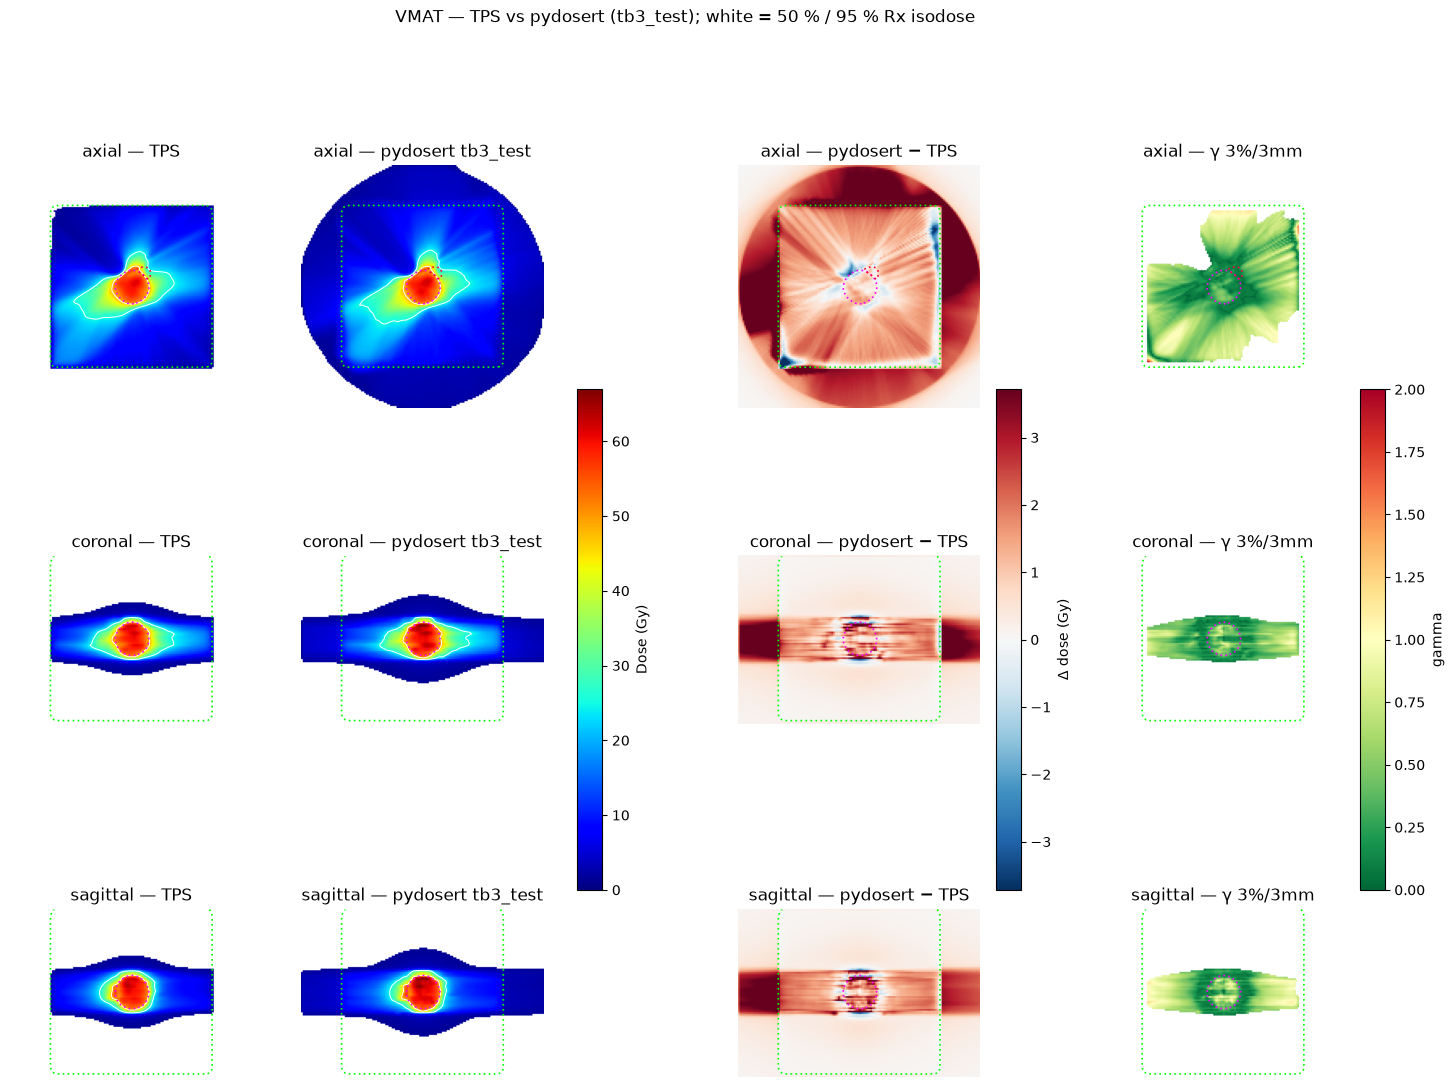

In [10]:
# Dose washes through the isocentre: TPS | pydosert | difference | 3%/3mm gamma
cz, cy, cx = iso_idx
planes = {
    "axial":    lambda a: a[cz],
    "coronal":  lambda a: a[:, cy],
    "sagittal": lambda a: a[:, :, cx],
}
vmax = float(max(dp.max(), rp.max()))
vlim = float(np.percentile(np.abs(diff[above_cutoff]), 99))
g33 = np.where(eval_mask, gamma[(3.0, 3.0)], np.nan)

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
for row, (title, slc) in zip(axes, planes.items()):
    for ax, arr, lab in ((row[0], rp, "TPS"), (row[1], dp, "pydosert tb3_test")):
        im_d = ax.imshow(np.ma.masked_less(slc(arr), 0.02 * vmax), cmap="jet", vmin=0, vmax=vmax)
        ax.contour(slc(arr), levels=[0.5 * rx_gy["Center"], 0.95 * rx_gy["Center"]],
                   colors="white", linewidths=0.7)
        ax.set_title(f"{title} — {lab}")
    im_x = row[2].imshow(slc(diff), cmap="RdBu_r", vmin=-vlim, vmax=vlim)
    row[2].set_title(f"{title} — pydosert − TPS")
    im_g = row[3].imshow(slc(g33), cmap="RdYlGn_r", vmin=0, vmax=2)
    row[3].set_title(f"{title} — γ 3%/3mm")
    for ax in row:
        plt.sca(ax)
        for name, mk in np_masks.items():
            s = slc(mk)
            if s.any():
                overlay_mask_outline(s, color=roi_colors[name], linewidth=1.2)
        ax.axis("off")
fig.colorbar(im_d, ax=axes[:, :2], shrink=0.5, label="Dose (Gy)")
fig.colorbar(im_x, ax=axes[:, 2], shrink=0.5, label="Δ dose (Gy)")
fig.colorbar(im_g, ax=axes[:, 3], shrink=0.5, label="gamma")
fig.suptitle("VMAT — TPS vs pydosert (tb3_test); white = 50 % / 95 % Rx isodose")
plt.show()

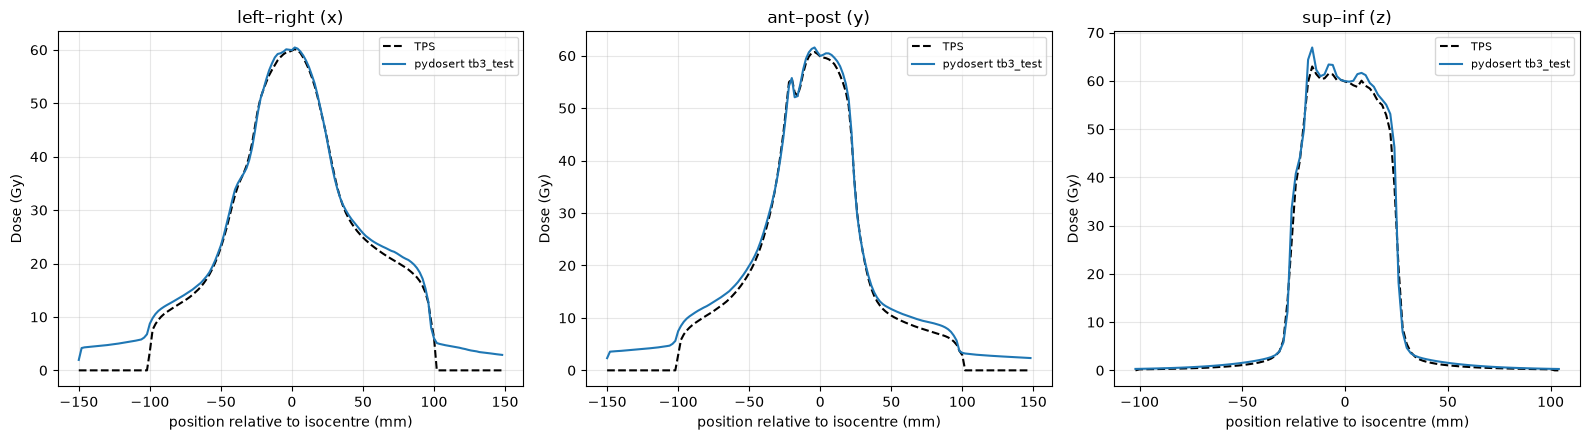

In [11]:
# Dose profiles through the isocentre along each grid axis
profiles = [
    ("left–right (x)", lambda a: a[cz, cy, :], 2),
    ("ant–post (y)",   lambda a: a[cz, :, cx], 1),
    ("sup–inf (z)",    lambda a: a[:, cy, cx], 0),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (title, prof, ax_i) in zip(axes, profiles):
    pos = (np.arange(rp.shape[ax_i]) - iso_idx[ax_i]) * res[ax_i]
    ax.plot(pos, prof(rp), "k--", lw=1.5, label="TPS")
    ax.plot(pos, prof(dp), "C0-", lw=1.5, label="pydosert tb3_test")
    ax.set_xlabel("position relative to isocentre (mm)")
    ax.set_ylabel("Dose (Gy)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

---
## Corrected model: stock `tb3_test` + **M4** (X jaws) + **M5** (DLG)

The comparison above uses the stock model. It leaves out two parts of the machine that
the TPS models:

* **M4: X jaws.** `FluenceMapLayer.forward` (pydosert 1.4.0) only applies the Y jaws. So:
  * the 1.5 % MLC transmission is applied across the full 400 mm field width instead of
    being blocked by the X jaws (±29 mm here). That adds about 1.5 Gy of leakage dose
    across the phantom;
  * the output-factor field sizes are estimated from a jaw mask that is uniform along
    the leaf-motion axis, so **both** read 400 mm, for the plan and for calibration.
    The output factor is then always OF(400) = 1.119, with no field-size dependence. For
    this plan's 58 × 54 mm jaws it should be 0.94, which is **6 % lower** relative to
    the 10 × 10 calibration field.

  The patched `forward` below is a copy of the stock one with only these two steps
  changed, both marked `# [M4]`. X-jaw positions come from the plan (recorded by M1). A
  beam without registered X jaws, i.e. the 10 × 10 auto-calibration beam, uses the
  outermost open leaves as its X jaws, so calibration stays 10 × 10.
* **M5: dosimetric leaf gap.** The `tb3_test` preset has `dlg_mm = None`. pydosert already
  supports a DLG, so this is only a config override. **1.0 mm was fitted to this TPS
  dose** (1.0 / 1.5 / 2.0 mm tested; 1.0 mm gave the best agreement). Replace it with the
  TPS beam-model DLG once that's known.

M4 is active **only inside the `with xjaw_fluence_model(...)` block**. On exiting the
block `FluenceMapLayer.forward` is restored automatically, even after an error, so
none of the other cells are affected. Switch the corrections off with the flags below.

In [12]:
# ---- Correction switches ---------------------------------------------------------------
APPLY_M4 = True    # [M4] X jaws in the fluence model      (False -> stock FluenceMapLayer)
DLG_MM = 1.0       # [M5] dosimetric leaf gap in mm         (None  -> stock tb3_test, no DLG)
# -----------------------------------------------------------------------------------------
import contextlib

from pydosert.layers.FluenceMapLayer import FluenceMapLayer
from pydosert.geometry.projections import fractional_box_overlap, resample_fluence_map
from pydosert.physics.fluence.fluence_modeling import (
    apply_directional_precomputed_kernel, apply_head_scatter_kernels,
    compute_sc_output_factor, estimate_field_size_1d, get_output_factor,
)

_M4_STATE = {"x_jaws": None,         # [G, 2] X-jaw positions (mm) of the beam sequence being computed
             "close_gap_mm": None}   # [M6] leaf pairs with a gap below this are treated as closed


def _fluence_forward_xjaw(self, leaf_positions, jaw_positions=None):
    """[M4] Copy of pydosert 1.4.0 FluenceMapLayer.forward, plus X jaws.
    Only the blocks marked [M4] (and the optional [M6] block) differ from the stock code."""
    B, G, N, _ = leaf_positions.shape
    leaf_positions = leaf_positions.reshape(B * G, N, 2)
    left_positions, right_positions = leaf_positions[..., 0], leaf_positions[..., 1]

    # [M6] (optional, off unless close_gap_mm is set) near-closed leaf pairs keep their planned gap
    #      but get no DLG widening (stock: every pair is widened by the DLG, see below)
    close_gap = _M4_STATE["close_gap_mm"]
    near_closed = ((right_positions - left_positions) < close_gap) if close_gap else None

    # [M4] X-jaw positions per beam: from the plan if registered, otherwise the outermost
    #      open leaves (the auto-calibration beam: leaves at +-50 mm -> 10 x 10 field)
    x_jaws = _M4_STATE["x_jaws"]
    if x_jaws is not None and x_jaws.shape[0] == B * G:
        x1, x2 = x_jaws[:, 0].to(self.dtype), x_jaws[:, 1].to(self.dtype)
    else:
        is_open = (right_positions - left_positions) > 0
        x1 = torch.where(is_open, left_positions, torch.full_like(left_positions, float("inf"))).min(1).values
        x2 = torch.where(is_open, right_positions, torch.full_like(right_positions, float("-inf"))).max(1).values
        x1, x2 = torch.nan_to_num(x1, posinf=0.0), torch.nan_to_num(x2, neginf=0.0)

    if self.dlg_half_mm > 0.0:
        dlg_half = torch.full_like(left_positions, self.dlg_half_mm)
        if near_closed is not None:                                              # [M6]
            dlg_half = torch.where(near_closed, torch.zeros_like(dlg_half), dlg_half)
        left_positions = left_positions - dlg_half
        right_positions = right_positions + dlg_half

    W = self.field_size[1]
    left_positions = left_positions.unsqueeze(1).repeat(1, W, 1)
    right_positions = right_positions.unsqueeze(1).repeat(1, W, 1)
    d = self.depth_indices.to(leaf_positions.device)

    mask = fractional_box_overlap(d, left_positions, right_positions,
                                  min_value=self.mlc_transmission, pixel_size=self.pixel_size_mm)
    mask = mask.view(B * G, W, N, 1)
    mask = resample_fluence_map(mask, self.leaf_widths, self.field_size[0], self.dtype)  # [BG, W, H, 1]

    # [M4] X-jaw aperture along W (leaf-motion axis): blocks the MLC transmission outside the jaws
    c = d[0, :, 0].view(1, W)                                   # pixel centres (mm)
    half = self.pixel_size_mm / 2
    x_open = ((torch.minimum(c + half, x2.view(-1, 1)) - torch.maximum(c - half, x1.view(-1, 1)))
              / self.pixel_size_mm).clamp(0, 1)                 # [BG, W]
    mask = mask * x_open.view(B * G, W, 1, 1)

    if jaw_positions is not None:
        jaw_positions = jaw_positions.reshape(B * G, 2)
        H = self.field_size[0]
        bottom = jaw_positions[:, 0].unsqueeze(1).unsqueeze(2).repeat(1, 1, H)
        top = jaw_positions[:, 1].unsqueeze(1).unsqueeze(2).repeat(1, 1, H)
        jaw_mask = fractional_box_overlap(self.jaw_indices.to(leaf_positions.device), bottom, top,
                                          pixel_size=self.pixel_size_mm)
        mask = mask * jaw_mask.view(B * G, 1, H, 1).repeat(1, W, 1, 1)

    aperture = mask.permute(0, 3, 2, 1)

    # [M4] OF / Sc field sizes from the actual jaw openings (stock: both read as 400 mm)
    field_size_x_mm = (x2 - x1).clamp(min=0)
    if jaw_positions is not None:
        field_size_y_mm = (jaw_positions[:, 1] - jaw_positions[:, 0]).to(self.dtype).clamp(min=0)
    else:
        field_size_y_mm = estimate_field_size_1d(aperture.mean(dim=3).squeeze(1), self.pixel_size_mm)

    # ---- unchanged stock physics pipeline -------------------------------------------------
    if self.use_penumbra:
        primary = apply_directional_precomputed_kernel(
            aperture, kernel_mlc=self.source_penumbra_kernel_mlc,
            kernel_jaw=self.source_penumbra_kernel_jaw, padding_mode="replicate").to(self.dtype)
    else:
        primary = aperture
    if self.use_profile_correction:
        primary = primary * self.profile_correction_map
    if self.use_head_scatter:
        scatter = apply_head_scatter_kernels(aperture, self.head_scatter_kernel_mlc,
                                             self.head_scatter_kernel_jaw).to(self.dtype)
        w = self.head_scatter_amplitude_mlc
        fluence_map = (1.0 - w) * primary + w * scatter
    else:
        fluence_map = primary
    if self.use_sc_model:
        sc = compute_sc_output_factor(jaw_w_mm=field_size_x_mm, jaw_h_mm=field_size_y_mm,
                                      sc_amplitude=self.sc_amplitude,
                                      sigma_x_mm=self.sc_sigma_x_mm, sigma_y_mm=self.sc_sigma_y_mm)
        fluence_map = sc[:, None, None, None] * fluence_map
    if self.use_output_factor:
        OF = get_output_factor(field_size_x_mm, field_size_y_mm, self.output_factors)
        fluence_map = OF[:, None, None, None] * fluence_map
    return fluence_map[:, 0, :, :]


@contextlib.contextmanager
def xjaw_fluence_model(x_jaws, enabled=True, close_gap_mm=None):
    """[M4] Temporarily swap in the X-jaw fluence model; the stock forward is always restored.
    close_gap_mm enables [M6] (no DLG widening for leaf pairs with a smaller gap); None = off."""
    if not enabled:
        yield
        return
    original = FluenceMapLayer.forward
    FluenceMapLayer.forward = _fluence_forward_xjaw
    _M4_STATE["x_jaws"] = x_jaws
    _M4_STATE["close_gap_mm"] = close_gap_mm
    try:
        yield
    finally:
        FluenceMapLayer.forward = original
        _M4_STATE["x_jaws"] = None
        _M4_STATE["close_gap_mm"] = None


print(f"M4 (X jaws) {'ON' if APPLY_M4 else 'OFF'}   M5 DLG = {DLG_MM} mm   "
      f"X jaws in plan: {float(xjaw_delivery[:, 0].min()):+.0f} / {float(xjaw_delivery[:, 1].max()):+.0f} mm")

M4 (X jaws) ON   M5 DLG = 1.0 mm   X jaws in plan: -29 / +29 mm


In [13]:
# Corrected dose: engine construction (auto-calibration) AND dose calc both inside the M4 block,
# so calibration and plan use the same fluence model.
machine_corr = MachineConfig(preset="tb3_test", dlg_mm=DLG_MM)            # [M5]

t0 = time.time()
with xjaw_fluence_model(xjaw_delivery, enabled=APPLY_M4):                  # [M4]
    engine_corr = DoseEngine(
        machine_config=machine_corr,
        kernel_size=151,
        dose_grid_spacing=res,
        dose_grid_shape=tuple(density.shape),
        device=DEVICE,
        dtype=DTYPE,
        auto_calibrate=True,
    )
    dose_corr_fx = engine_corr.compute_dose(delivery, density_image=density).squeeze(0)
print(f"corrected dose computed in {time.time() - t0:.0f} s   "
      f"(FluenceMapLayer.forward restored: {FluenceMapLayer.forward.__name__ == 'forward'})")

dc = dose_corr_fx.cpu().numpy() * n_fx          # corrected pydosert, full course (Gy)
diff_c = dc - rp
print(f"corrected Dmax = {dc.max():.2f} Gy   stock Dmax = {dp.max():.2f} Gy   TPS Dmax = {rp.max():.2f} Gy")

corrected dose computed in 65 s   (FluenceMapLayer.forward restored: True)
corrected Dmax = 65.13 Gy   stock Dmax = 66.93 Gy   TPS Dmax = 64.13 Gy


In [14]:
# Stock vs corrected vs TPS: key metrics (Δ % relative to TPS)
low_dose = np_masks["BODY"] & (rp > 0.02 * rp.max()) & (rp < 0.20 * rp.max())
rows = [("dose at isocentre", lambda a: a[iso_idx])]
for name in np_masks:
    rows.append((f"{name} Dmean", lambda a, m=np_masks[name]: a[m].mean()))
rows += [
    ("Center D98%", lambda a: dose_at_volume_percent(a, np_masks["Center"], 98.0)),
    ("Center D2%",  lambda a: dose_at_volume_percent(a, np_masks["Center"], 2.0)),
    ("Center V100%Rx (%)", lambda a: volume_at_dose(a, np_masks["Center"], rx_gy["Center"])),
    ("BODY 2–20 % isodose Dmean", lambda a: a[low_dose].mean()),
]
print(f"{'metric':28s} {'TPS':>9s} {'stock':>9s} {'Δ %':>7s} {'corrected':>10s} {'Δ %':>7s}")
for label, f in rows:
    t, s, c = float(f(rp)), float(f(dp)), float(f(dc))
    print(f"{label:28s} {t:9.2f} {s:9.2f} {100 * (s / t - 1):+7.1f} {c:10.2f} {100 * (c / t - 1):+7.1f}")

print("\nvoxel-wise difference, dose > 10% max:")
for tag, arr in (("stock", dp), ("corrected", dc)):
    d = (arr - rp)[above_cutoff]
    print(f"  {tag:10s} mean Δ={d.mean():+6.2f}  mean |Δ|={np.abs(d).mean():5.2f}  "
          f"RMSE={np.sqrt((d ** 2).mean()):5.2f}  95th |Δ|={np.percentile(np.abs(d), 95):5.2f}  (Gy)")

metric                             TPS     stock     Δ %  corrected     Δ %
dose at isocentre                59.87     59.95    +0.1      57.67    -3.7
BODY Dmean                        3.18      3.70   +16.5       3.28    +3.3
Center Dmean                     55.18     56.97    +3.2      55.27    +0.2
Avoid1 Dmean                     31.79     32.19    +1.3      32.57    +2.4
Avoid2 Dmean                     18.89     16.35   -13.5      18.68    -1.1
Center D98%                      48.16     48.95    +1.6      48.10    -0.1
Center D2%                       62.00     64.82    +4.6      63.05    +1.7
Center V100%Rx (%)               92.02     96.57    +4.9      92.06    +0.0
BODY 2–20 % isodose Dmean         5.62      6.95   +23.6       5.76    +2.4

voxel-wise difference, dose > 10% max:
  stock      mean Δ= +1.50  mean |Δ|= 1.59  RMSE= 1.74  95th |Δ|= 2.59  (Gy)
  corrected  mean Δ= +0.20  mean |Δ|= 0.60  RMSE= 1.00  95th |Δ|= 2.16  (Gy)


In [15]:
# Gamma, stock vs corrected (same criteria and evaluation mask as above)
gamma_corr = {}
print(f"{'criterion':10s} {'stock pass':>11s} {'corrected pass':>15s} {'corrected mean γ':>17s}")
for dd, dta in ((3.0, 3.0), (2.0, 2.0)):
    g = pymedphys.gamma(
        axes_reference=axes_mm, dose_reference=rp,
        axes_evaluation=axes_mm, dose_evaluation=dc,
        dose_percent_threshold=dd, distance_mm_threshold=dta,
        lower_percent_dose_cutoff=10.0, interp_fraction=10, max_gamma=2.0,
        global_normalisation=rp.max(), local_gamma=False, quiet=True,
    )
    gamma_corr[(dd, dta)] = g
    vc = g[eval_mask]; vc = vc[~np.isnan(vc)]
    vs = gamma[(dd, dta)][eval_mask]; vs = vs[~np.isnan(vs)]
    print(f"{dd:.0f}%/{dta:.0f}mm    {(vs <= 1).mean() * 100:10.1f}% {(vc <= 1).mean() * 100:14.1f}% "
          f"{vc.mean():17.3f}")

criterion   stock pass  corrected pass  corrected mean γ


C:\Users\mross\AppData\Local\Temp\ipykernel_7388\3636354421.py:5: DeprecationWarning: Parameter `quiet` will be deprecated in the future
  g = pymedphys.gamma(


3%/3mm          97.7%           99.9%             0.145
2%/2mm          69.5%           99.3%             0.207


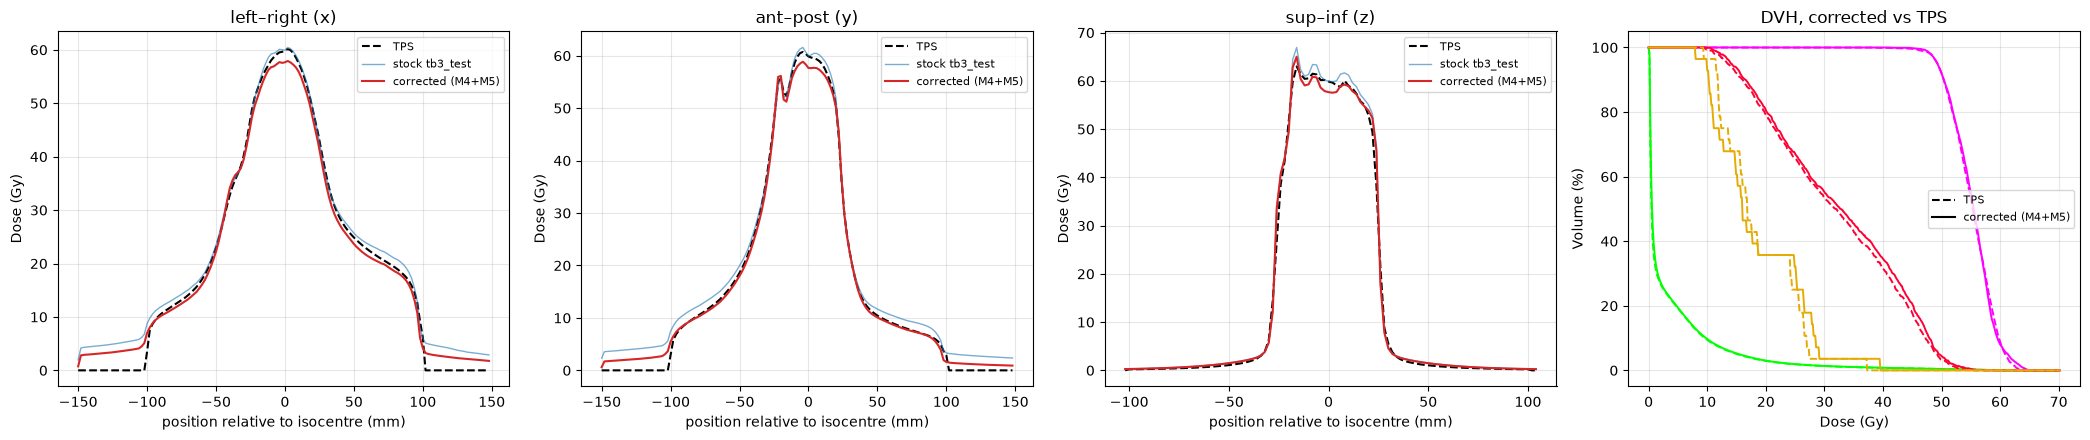

In [16]:
# Profiles through the isocentre and DVH: TPS vs stock vs corrected
fig, axes = plt.subplots(1, 4, figsize=(21, 4.5))
for ax, (title, prof, ax_i) in zip(axes, profiles):
    pos = (np.arange(rp.shape[ax_i]) - iso_idx[ax_i]) * res[ax_i]
    ax.plot(pos, prof(rp), "k--", lw=1.5, label="TPS")
    ax.plot(pos, prof(dp), "C0-", lw=1.0, alpha=0.6, label="stock tb3_test")
    ax.plot(pos, prof(dc), "C3-", lw=1.5, label="corrected (M4+M5)")
    ax.set_xlabel("position relative to isocentre (mm)")
    ax.set_ylabel("Dose (Gy)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

ax = axes[3]
bins = np.linspace(0, max(dp.max(), dc.max(), rp.max()) * 1.05, 500)
for name, mk in np_masks.items():
    for arr, ls in ((rp, "--"), (dc, "-")):
        h, edges = np.histogram(arr[mk], bins=bins)
        ax.plot(edges[:-1], 100 * np.cumsum(h[::-1])[::-1] / h.sum(), ls=ls, color=roi_colors[name], lw=1.4)
ax.plot([], [], "k--", label="TPS")
ax.plot([], [], "k-", label="corrected (M4+M5)")
ax.set_xlabel("Dose (Gy)")
ax.set_ylabel("Volume (%)")
ax.set_title("DVH, corrected vs TPS")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

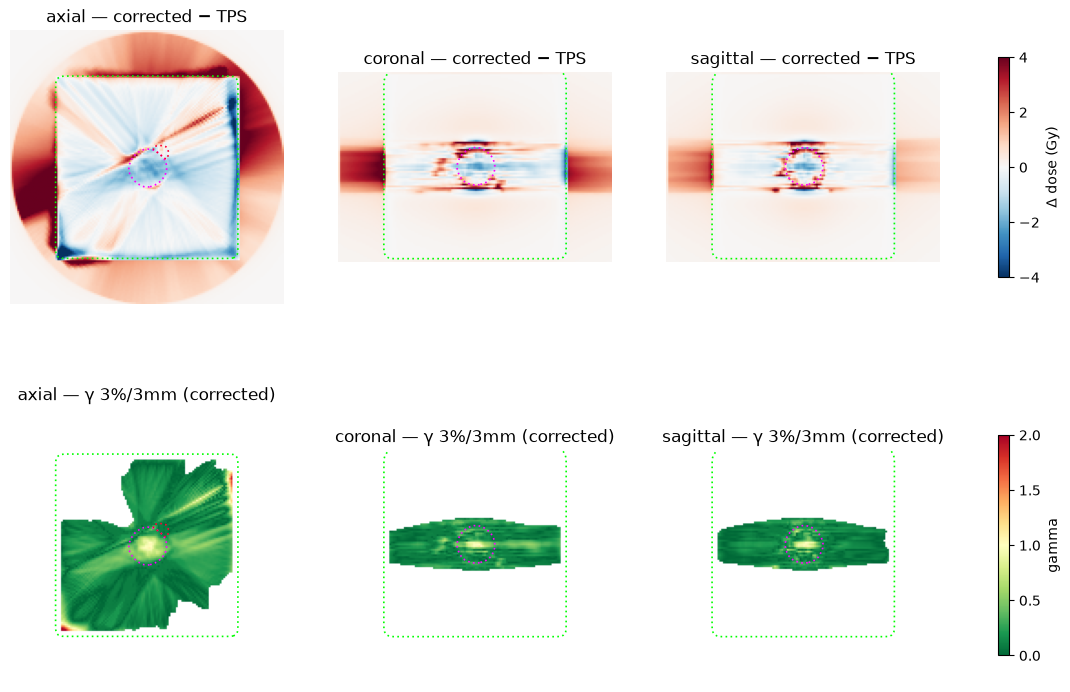

In [17]:
# Corrected model: difference and 3%/3mm gamma through the isocentre
vlim_c = float(np.percentile(np.abs(diff_c[above_cutoff]), 99))
g33c = np.where(eval_mask, gamma_corr[(3.0, 3.0)], np.nan)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for j, (title, slc) in enumerate(planes.items()):
    im_x = axes[0, j].imshow(slc(diff_c), cmap="RdBu_r", vmin=-vlim_c, vmax=vlim_c)
    axes[0, j].set_title(f"{title} — corrected − TPS")
    im_g = axes[1, j].imshow(slc(g33c), cmap="RdYlGn_r", vmin=0, vmax=2)
    axes[1, j].set_title(f"{title} — γ 3%/3mm (corrected)")
    for ax in axes[:, j]:
        plt.sca(ax)
        for name, mk in np_masks.items():
            s = slc(mk)
            if s.any():
                overlay_mask_outline(s, color=roi_colors[name], linewidth=1.2)
        ax.axis("off")
fig.colorbar(im_x, ax=axes[0], shrink=0.7, label="Δ dose (Gy)")
fig.colorbar(im_g, ax=axes[1], shrink=0.7, label="gamma")
plt.show()

---
## Avoid2: why it differs, and the refined model (M6 + M7, compared on the TPS grid, C1)

Avoid2 is tiny (0.22 cm³, 28 voxels on the 2 mm grid) and sits in the steepest dose gradient
of the plan (≈5 Gy/mm, vs ≈1.2 Gy/mm in `Center`), so 0.1 mm of edge position is ≈3 % of its
dose. Three separate effects make its DVH differ:

1. **A streak from near-closed leaf pairs → M6.** From gantry 47° to 63°, the arc's heaviest
   segments (up to 36 MU each, ≈150 MU in total), the two central leaf pairs are parked
   1.1 mm apart. pydosert widens every gap by the DLG, turning this one into a 2.1 mm fully
   open slit. That puts a straight streak of +2–4 Gy along that beam direction, through
   Avoid2 and along Avoid1's edge (map below). The TPS only lets a thin sliver through
   (visible as a checkerboard where its 2 mm grid samples that line). **M6** keeps the
   planned gap of pairs < 1.5 mm apart but doesn't add the DLG to them. Closing them fully
   was also tested; it overcorrects into a cold streak.
2. **Interpolating the TPS dose → C1.** The earlier sections interpolate the TPS dose onto
   pydosert's grid, which is offset by 0.59 / 0.50 voxel in-plane and uses 2.0 mm slices
   instead of 2.5 mm. In a strongly curved 5 Gy/mm gradient, linear interpolation alone
   moves Avoid2's mean by several percent. `Center` and Avoid1 move by < 1 %.
   **C1** computes pydosert on a grid whose points coincide with the TPS grid and compares
   the two with no interpolation.
3. **Leaf-end penumbra → M7.** With 1 and 2 fixed, the dose beyond the leaf tips (Avoid2's
   far side) is still too steep. Rounded leaf ends give a broader tail than the sharp edge
   `tb3_test` models with a 1.18 mm source penumbra. **M7** widens **only** the leaf-end
   (MLC-direction) penumbra to 2.0 mm (tested 2.0 / 2.5 / 3.0 mm on the TPS grid).

Checked and rejected: a global geometric offset (best-fit rigid shift < 0.3 mm),
blurring the whole dose (raises all of Avoid2), MLC transmission (fixes Avoid2 only by
making Avoid1 and the low-dose region worse), and a wider penumbra in both directions.

**Limit:** on the TPS grid Avoid2 has only 20 voxels, so its **D98 is effectively one
voxel**, the corner furthest from the target. It stays about 15 % low under every
variant tested. Read D50 / D2 / mean for Avoid2, not D98.

cp  gantry  segment MU  central leaf pairs (left, right) mm   gap
111     43       6.42   ( -19.3, -14.1) ( -19.3, -15.7)    3.6
112     45       7.98   ( -19.2, -15.7) ( -19.3, -15.7)    3.5
113     47       8.60   ( -19.3, -18.1) ( -19.3, -18.1)    1.2
114     49       8.78   ( -19.2, -18.2) ( -19.2, -18.2)    1.0
115     51       8.60   ( -19.3, -18.2) ( -19.3, -18.2)    1.1
116     53       8.78   ( -19.2, -18.2) ( -19.2, -17.8)    1.0
117     55       8.04   ( -19.3, -18.2) ( -19.3, -18.2)    1.1
118     57      10.87   ( -19.2, -18.2) ( -19.2, -18.2)    1.0
119     59      16.71   ( -19.3, -18.2) ( -19.3, -18.2)    1.1
120     61      36.42   ( -19.2, -18.2) ( -19.2, -18.2)    1.0
121     63      27.17   ( -19.3, -18.2) ( -19.3, -18.2)    1.1
122     65      14.54   ( -19.3, -17.6) ( -19.3, -15.5)    1.7


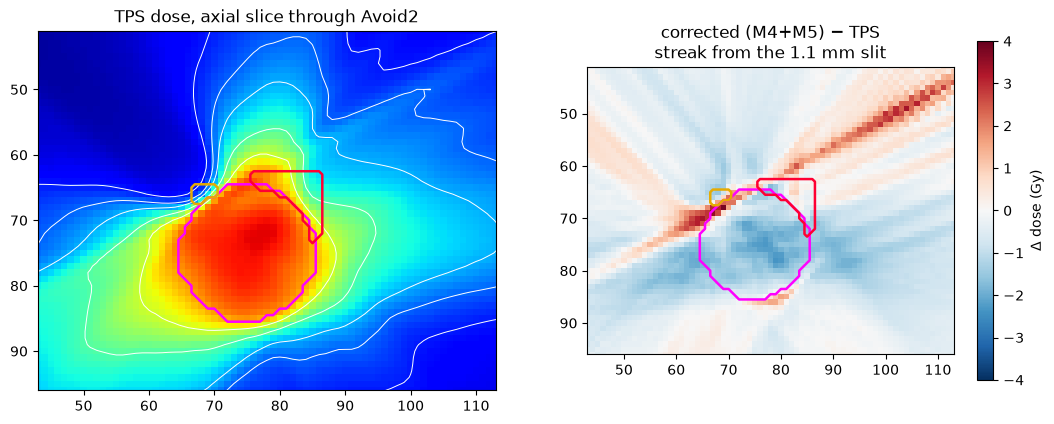

In [18]:
# Evidence for M6: central leaf pairs (rows covering the isocentre plane) during gantry 41–65 deg
from scipy import ndimage

_rp = pydicom.dcmread(rtplan_path)
_b = _rp.BeamSequence[0]
_mlc = next(d for d in _b.BeamLimitingDeviceSequence if d.RTBeamLimitingDeviceType == "MLCX")
_bounds = np.array([float(v) for v in _mlc.LeafPositionBoundaries])
_rows = np.where((_bounds[:-1] < 5) & (_bounds[1:] > -5))[0]
_lp = control_points.leaf_positions.numpy()
_g = control_points.gantry_angles_deg
_mu_seg = control_points.mus.numpy()                 # MU delivered up to each control point from the previous one
print("cp  gantry  segment MU  central leaf pairs (left, right) mm   gap")
for i in np.where((_g >= 41) & (_g <= 65))[0]:
    pairs = " ".join(f"({_lp[i, r, 0]:+6.1f},{_lp[i, r, 1]:+6.1f})" for r in _rows)
    print(f"{i:3d} {_g[i]:6.0f}  {_mu_seg[i]:9.2f}   {pairs}   {_lp[i, _rows, 1].min() - _lp[i, _rows, 0].max():4.1f}")

# the streak: corrected (M4+M5) − TPS around Avoid2, on the CT grid used above
a2z, a2y, a2x = np.array(ndimage.center_of_mass(np_masks["Avoid2"])).round().astype(int)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].imshow(rp[a2z], cmap="jet", vmin=0, vmax=vmax)
axes[0].contour(rp[a2z], levels=[10, 15, 20, 30, 40], colors="w", linewidths=0.7)
axes[0].set_title("TPS dose, axial slice through Avoid2")
im = axes[1].imshow(diff_c[a2z], cmap="RdBu_r", vmin=-4, vmax=4)
axes[1].set_title("corrected (M4+M5) − TPS\nstreak from the 1.1 mm slit")
for ax in axes:
    for name in ("Center", "Avoid1", "Avoid2"):          # plain contour: tiny Avoid2 stays visible
        ax.contour(np_masks[name][a2z], levels=[0.5], colors=[roi_colors[name]], linewidths=1.8)
    ax.set_xlim(a2x - 25, a2x + 45); ax.set_ylim(a2y + 30, a2y - 25)
fig.colorbar(im, ax=axes[1], shrink=0.8, label="Δ dose (Gy)")
plt.show()

In [19]:
# [C1] pydosert grid aligned with the TPS dose grid, extended to cover the whole phantom
from pydosert.data.utils.dicom_utils import load_ct_series, load_structures

_rd = pydicom.dcmread(rtdose_path)
tps = _rd.pixel_array.astype(np.float64) * float(_rd.DoseGridScaling)          # (z, y, x), Gy, full course
res_rd = (float(_rd.GridFrameOffsetVector[1]) - float(_rd.GridFrameOffsetVector[0]),
          float(_rd.PixelSpacing[0]), float(_rd.PixelSpacing[1]))                 # (z, y, x) mm
origin_rd = np.array(_rd.ImagePositionPatient, float)[::-1]                        # (z, y, x) mm
PAD = np.array([1, 25, 25])        # voxels added on each side so the grid holds the whole phantom
origin_ext = origin_rd - PAD * np.array(res_rd)
shape_ext = tuple(int(n) for n in np.array(tps.shape) + 2 * PAD)
crop = tuple(slice(int(p), int(p + n)) for p, n in zip(PAD, tps.shape))       # extended grid -> TPS grid

# structures: fine CT-grid masks -> fractional occupancy on the TPS grid (5 x 5 in-plane supersampling)
_ct_img, _ = load_ct_series(ct_folder)
_fine = load_structures(_ct_img, ct_folder, rtstruct_path, struct_names=list(roi_colors))
SS = 5
_sup = sitk.Image([shape_ext[2] * SS, shape_ext[1] * SS, shape_ext[0]], sitk.sitkFloat32)
_sup.SetSpacing((res_rd[2] / SS, res_rd[1] / SS, res_rd[0]))
_sup.SetOrigin((origin_ext[2] - res_rd[2] / 2 + res_rd[2] / SS / 2,
                origin_ext[1] - res_rd[1] / 2 + res_rd[1] / SS / 2, origin_ext[0]))
masks_ext = {}
for name, img in _fine.items():
    a = sitk.GetArrayFromImage(sitk.Resample(img, _sup, sitk.Transform(), sitk.sitkNearestNeighbor, 0.0, sitk.sitkFloat32))
    masks_ext[name] = a.reshape(shape_ext[0], shape_ext[1], SS, shape_ext[2], SS).mean(axis=(2, 4)) >= 0.5
masks_rd = {name: m[crop] for name, m in masks_ext.items()}

density_rd = torch.from_numpy(np.where(masks_ext["BODY"], body_red, 0.0012)).to(DTYPE)
_iso_dicom = np.array([float(v) for v in _b.ControlPointSequence[0].IsocenterPosition])[::-1]   # (z, y, x)
delivery_rd = dataclasses.replace(delivery, iso_center=tuple(_iso_dicom - origin_ext))

print(f"TPS grid {tps.shape} @ {res_rd} mm; extended calc grid {shape_ext}")
print("voxels on the TPS grid:", {k: int(m.sum()) for k, m in masks_rd.items()},
      "  (CT grid:", {k: int(m.sum()) for k, m in np_masks.items()}, ")")

TPS grid (81, 101, 101) @ (2.5, 2.0, 2.0) mm; extended calc grid (83, 151, 151)
voxels on the TPS grid: {'BODY': 809996, 'Center': 3712, 'Avoid1': 1138, 'Avoid2': 20}   (CT grid: {'BODY': 1009503, 'Center': 4688, 'Avoid1': 1276, 'Avoid2': 28} )


In [20]:
# ---- Refinement switches ---------------------------------------------------------------
CLOSE_GAP_MM = 1.5   # [M6] no DLG for leaf pairs with gap < this   (None -> off)
PEN_MLC_MM = 2.0     # [M7] leaf-end source penumbra FWHM (mm)       (None -> stock 1.1775)
# -----------------------------------------------------------------------------------------
_pen_stock = list(MachineConfig(preset="tb3_test").penumbra_fwhm)       # [MLC, jaw] = [1.1775, 1.1775]


def dose_on_tps_grid(close_gap_mm=None, pen_mlc_mm=None):
    """Full-course dose on the TPS grid: M4 + M5, plus optional M6 / M7."""
    pen = [pen_mlc_mm if pen_mlc_mm is not None else _pen_stock[0], _pen_stock[1]]
    mc = MachineConfig(preset="tb3_test", dlg_mm=DLG_MM, penumbra_fwhm=pen)                     # [M5] [M7]
    with xjaw_fluence_model(xjaw_delivery, enabled=APPLY_M4, close_gap_mm=close_gap_mm):        # [M4] [M6]
        eng = DoseEngine(machine_config=mc, kernel_size=151, dose_grid_spacing=res_rd,
                         dose_grid_shape=shape_ext, device=DEVICE, dtype=DTYPE, auto_calibrate=True)
        d = eng.compute_dose(delivery_rd, density_image=density_rd).squeeze(0).cpu().numpy()
    return d[crop] * n_fx


t0 = time.time()
dc_rd = dose_on_tps_grid()                                                   # corrected (M4+M5), TPS grid
dr_rd = dose_on_tps_grid(close_gap_mm=CLOSE_GAP_MM, pen_mlc_mm=PEN_MLC_MM)   # refined (M4–M7), TPS grid
print(f"both computed in {time.time() - t0:.0f} s   M6 gap < {CLOSE_GAP_MM} mm, M7 leaf-end penumbra "
      f"{PEN_MLC_MM} mm   (FluenceMapLayer.forward stock again: {FluenceMapLayer.forward.__name__ == 'forward'})")

both computed in 158 s   M6 gap < 1.5 mm, M7 leaf-end penumbra 2.0 mm   (FluenceMapLayer.forward stock again: True)


In [21]:
# Δ % vs TPS on the TPS grid (no interpolation): corrected (M4+M5) vs refined (M4–M7)
def dvh_row(a, m):
    return np.array([dose_at_volume_percent(a, m, 98.0), dose_at_volume_percent(a, m, 50.0),
                     dose_at_volume_percent(a, m, 2.0), a[m].mean()])


print(f"{'ROI':8s} {'TPS D98 / D50 / D2 / mean (Gy)':>34s}   {'corrected Δ%':^27s}   {'refined Δ%':^27s}")
for name, mk in masks_rd.items():
    t = dvh_row(tps, mk)
    c = 100 * (dvh_row(dc_rd, mk) / t - 1)
    r = 100 * (dvh_row(dr_rd, mk) / t - 1)
    print(f"{name:8s} {' '.join(f'{x:7.2f}' for x in t)}   {' '.join(f'{x:+6.1f}' for x in c)}   "
          f"{' '.join(f'{x:+6.1f}' for x in r)}")
_low_rd = masks_rd["BODY"] & (tps > 0.02 * tps.max()) & (tps < 0.20 * tps.max())
print(f"BODY 2–20 % isodose mean: corrected {100 * (dc_rd[_low_rd].mean() / tps[_low_rd].mean() - 1):+.1f} %   "
      f"refined {100 * (dr_rd[_low_rd].mean() / tps[_low_rd].mean() - 1):+.1f} %")
print(f"Avoid2 has {int(masks_rd['Avoid2'].sum())} voxels here: its D98 is effectively a single voxel.")

axes_rd = tuple(np.arange(tps.shape[i]) * res_rd[i] for i in range(3))
eval_rd = binary_erosion(masks_rd["BODY"], np.ones((3, 3, 3)), iterations=3) & (tps > 0.1 * tps.max())
print(f"\n{'gamma (TPS grid)':16s} {'corrected':>10s} {'refined':>9s}")
for dd in (3.0, 2.0, 1.0):
    rates = []
    for arr in (dc_rd, dr_rd):
        g = pymedphys.gamma(axes_rd, tps, axes_rd, arr, dd, dd, lower_percent_dose_cutoff=10.0,
                            interp_fraction=10, max_gamma=2.0, global_normalisation=tps.max(),
                            local_gamma=False, quiet=True)[eval_rd]
        g = g[~np.isnan(g)]
        rates.append((g <= 1).mean() * 100)
    print(f"{dd:.0f}%/{dd:.0f}mm global     {rates[0]:9.1f}% {rates[1]:8.1f}%")

ROI          TPS D98 / D50 / D2 / mean (Gy)          corrected Δ%                   refined Δ%         
BODY        0.13    0.48   24.10    3.18    +17.6  +26.0   +0.1   +3.1    +16.0  +24.2   -0.8   +1.7
Center     48.60   55.50   62.32   55.43     +0.1   +0.4   +0.9   +0.1     -0.4   -0.4   +0.3   -0.6
Avoid1     10.81   30.49   51.69   31.17     +8.0   +3.2   +2.5   +2.6     +1.8   +1.9   -1.4   +0.9
Avoid2      9.34   15.68   39.62   19.90    -16.1   +2.8   +5.6   +2.1    -16.5   +3.7   -1.3   +0.1
BODY 2–20 % isodose mean: corrected +1.7 %   refined +0.0 %
Avoid2 has 20 voxels here: its D98 is effectively a single voxel.

gamma (TPS grid)  corrected   refined


C:\Users\mross\AppData\Local\Temp\ipykernel_7388\1112542107.py:25: DeprecationWarning: Parameter `quiet` will be deprecated in the future
  g = pymedphys.gamma(axes_rd, tps, axes_rd, arr, dd, dd, lower_percent_dose_cutoff=10.0,


3%/3mm global          99.8%     99.8%
2%/2mm global          99.1%     98.9%
1%/1mm global          91.6%     92.3%


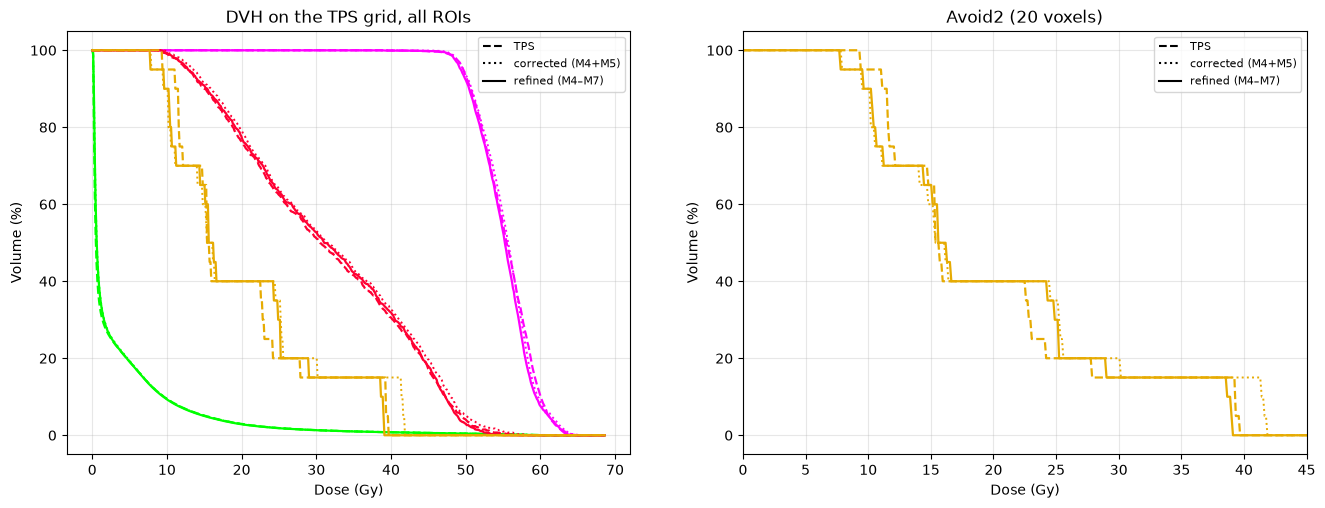

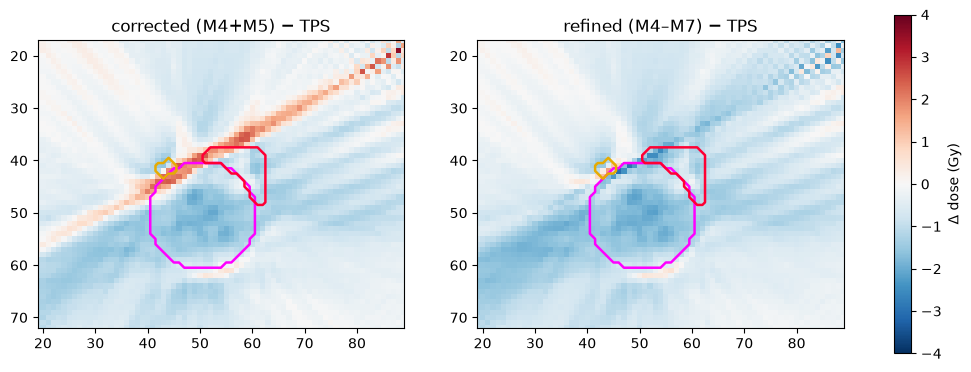

In [22]:
# DVHs on the TPS grid: TPS vs corrected vs refined (left: all ROIs, right: Avoid2 zoomed)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
bins = np.linspace(0, max(tps.max(), dc_rd.max(), dr_rd.max()) * 1.05, 600)
for ax, names in ((axes[0], list(masks_rd)), (axes[1], ["Avoid2"])):
    for name in names:
        mk = masks_rd[name]
        for arr, ls, lw in ((tps, "--", 1.6), (dc_rd, ":", 1.4), (dr_rd, "-", 1.6)):
            h, edges = np.histogram(arr[mk], bins=bins)
            ax.plot(edges[:-1], 100 * np.cumsum(h[::-1])[::-1] / h.sum(), ls=ls, lw=lw, color=roi_colors[name])
    for ls, lab in (("--", "TPS"), (":", "corrected (M4+M5)"), ("-", "refined (M4–M7)")):
        ax.plot([], [], "k", ls=ls, label=lab)
    ax.set_xlabel("Dose (Gy)"); ax.set_ylabel("Volume (%)"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_title("DVH on the TPS grid, all ROIs")
axes[1].set_title(f"Avoid2 ({int(masks_rd['Avoid2'].sum())} voxels)")
axes[1].set_xlim(0, 45)
plt.show()

# difference maps through Avoid2 on the TPS grid
z2, y2, x2 = np.array(ndimage.center_of_mass(masks_rd["Avoid2"])).round().astype(int)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, arr, title in ((axes[0], dc_rd, "corrected (M4+M5) − TPS"), (axes[1], dr_rd, "refined (M4–M7) − TPS")):
    im = ax.imshow((arr - tps)[z2], cmap="RdBu_r", vmin=-4, vmax=4)
    for name in ("Center", "Avoid1", "Avoid2"):
        ax.contour(masks_rd[name][z2], levels=[0.5], colors=[roi_colors[name]], linewidths=1.8)
    ax.set_xlim(x2 - 25, x2 + 45); ax.set_ylim(y2 + 30, y2 - 25); ax.set_title(title)
fig.colorbar(im, ax=axes, shrink=0.8, label="Δ dose (Gy)")
plt.show()

---
## Reverting the modifications

| To undo | Do this |
|---------|---------|
| everything | **restart the kernel**. Nothing is changed on disk, so a fresh kernel is stock pydosert. |
| M1 + M2 (global patches) | run `revert_pydosert_patches()` below. Without M1, `load_dicom` can't read this plan (missing SSD). |
| M3 | replace the `delivery = dataclasses.replace(...)` line with `delivery = control_points.to_delivery()`. |
| M4 | `APPLY_M4 = False`. Nothing to undo afterwards: the patch only exists inside the `with` block. |
| M5 | `DLG_MM = None`. |
| M6 | `CLOSE_GAP_MM = None`. It only runs inside the M4 `with` block, so nothing to undo afterwards. |
| M7 | `PEN_MLC_MM = None` (stock 1.1775 mm). |
| C1 | nothing to undo: it only defines the TPS-grid variables (`tps`, `masks_rd`, `dc_rd`, `dr_rd`, …). The earlier sections are the CT-grid comparison. |

With `APPLY_M4 = False` and `DLG_MM = None`, the corrected section reproduces the stock
result exactly. With `CLOSE_GAP_MM = None` and `PEN_MLC_MM = None`, the refined dose
equals the corrected dose on the TPS grid. Use these as sanity checks after changing anything.

In [23]:
# What's patched right now? (M4 should never appear here: it's scoped to its `with` block)
list_pydosert_patches()
print("FluenceMapLayer.forward is stock:", FluenceMapLayer.forward.__name__ == "forward")

# Uncomment to restore stock pydosert for M1 + M2 in this kernel:
# revert_pydosert_patches()

  [M1] pydosert.data.loaders.fetch_plan_data
  [M2] BeamWiseConvolutionalLayer.forward
FluenceMapLayer.forward is stock: True


---
## Final comparison: refined model (M4–M7) vs TPS, on the TPS grid

DVH and dose difference using only the refined pydosert dose (`dr_rd`) and the TPS dose
(`tps`), both on the TPS grid with no interpolation (C1). Requires the *Refined model*
section to have been run.

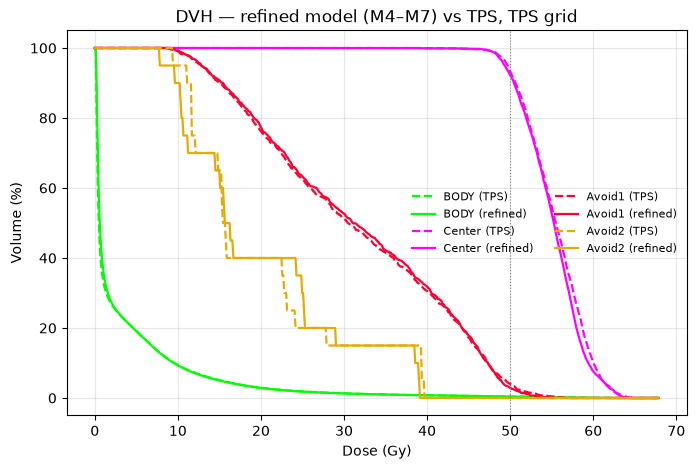

In [27]:
# DVH on the TPS grid: TPS (dashed) vs refined model (solid), all ROIs
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, max(tps.max(), dr_rd.max()) * 1.05, 600)
for name, mk in masks_rd.items():
    for arr, ls, tag in ((tps, "--", "TPS"), (dr_rd, "-", "refined")):
        h, edges = np.histogram(arr[mk], bins=bins)
        ax.plot(edges[:-1], 100 * np.cumsum(h[::-1])[::-1] / h.sum(), ls=ls,
                color=roi_colors[name], lw=1.6, label=f"{name} ({tag})")
ax.axvline(rx_gy["Center"], color="gray", lw=0.8, ls=":")
ax.set_xlabel("Dose (Gy)")
ax.set_ylabel("Volume (%)")
ax.set_title("DVH — refined model (M4–M7) vs TPS, TPS grid")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2, frameon = False)
plt.savefig('refined-vs-tps.pdf', dpi = 600)
plt.show()

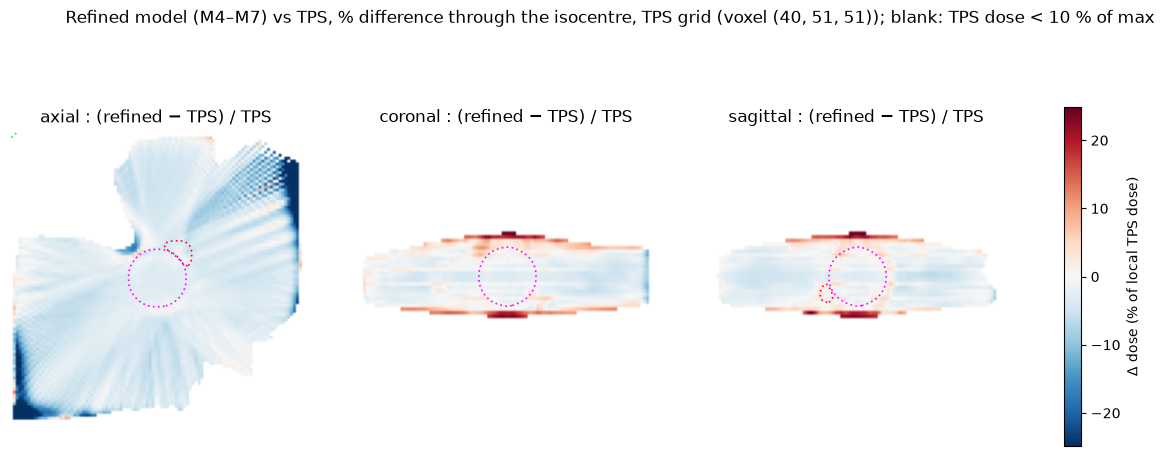

(refined − TPS) / TPS, dose > 10% max: mean Δ=-1.08  mean |Δ|=3.88  RMS=6.33  95th |Δ|=12.06  (%)


In [30]:
# Percent dose difference, 100 × (refined − TPS) / TPS, through the isocentre on the TPS grid.
# Local difference: shown only where TPS dose > 10 % of its max (below that the ratio blows up).
iso_rd = tuple(int(round(v)) for v in (_iso_dicom - origin_rd) / np.array(res_rd))
above_rd = tps > 0.10 * tps.max()
pct_r = np.full(tps.shape, np.nan)
pct_r[above_rd] = 100.0 * (dr_rd[above_rd] - tps[above_rd]) / tps[above_rd]
vlim_r = float(np.percentile(np.abs(pct_r[above_rd]), 99))
rz, ry, rx = iso_rd
slab_aspect = res_rd[0] / res_rd[1]           # 2.5 mm slices vs 2.0 mm in-plane
planes_rd = {                                  # (slice, display aspect)
    "axial":    (lambda a: a[rz], 1.0),
    "coronal":  (lambda a: a[:, ry], slab_aspect),
    "sagittal": (lambda a: a[:, :, rx], slab_aspect),
}
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, (title, (slc, asp)) in zip(axes, planes_rd.items()):
    im = ax.imshow(slc(pct_r), cmap="RdBu_r", vmin=-vlim_r, vmax=vlim_r, aspect=asp)
    ax.set_title(f"{title} : (refined − TPS) / TPS")
    plt.sca(ax)
    for name, mk in masks_rd.items():
        s = slc(mk)
        if s.any():
            overlay_mask_outline(s, color=roi_colors[name], linewidth=1.2)
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.8, label="Δ dose (% of local TPS dose)")
fig.suptitle(f"Refined model (M4–M7) vs TPS, % difference through the isocentre, TPS grid (voxel {iso_rd}); "
             "blank: TPS dose < 10 % of max")
#plt.savefig('dose-diff-iso.pdf', dpi = 600)
plt.show()

d = pct_r[above_rd]
print(f"(refined − TPS) / TPS, dose > 10% max: mean Δ={d.mean():+.2f}  mean |Δ|={np.abs(d).mean():.2f}  "
      f"RMS={np.sqrt((d ** 2).mean()):.2f}  95th |Δ|={np.percentile(np.abs(d), 95):.2f}  (%)")